In [1]:
# ===== CELL 1: SETUP =====

import os, torch, numpy as np, cv2, gc
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

print("Device:", device)

Device: cuda


In [2]:
# ===== CELL 2: CONFIG =====

NPY_PATH = "F:/BraTS/BraTS_npy"
SAVE_DIR = "F:/BraTS/BraTS_models"

IMG_SIZE = 160
BATCH_SIZE = 2
EPOCHS = 10
LR = 3e-4

os.makedirs(SAVE_DIR, exist_ok=True)

In [3]:
# ===== CELL 3: DATASET (STAGE 2 - FAST BALANCED SAMPLING) =====

import random
import numpy.lib.format as np_fmt
from collections import defaultdict

class UltraDataset(Dataset):
    def __init__(self, path, empty_ratio=0.25, cache_size=50):
        self.files = [os.path.join(path, f) for f in os.listdir(path)]
        # Shuffling the files ensures the patients are in random order
        np.random.shuffle(self.files)

        tumor_map = []
        empty_map = []

        print("Scanning dataset (Stage 2 balancing)...")

        self.cache = {}
        self.order = []
        self.cache_size = cache_size

        total = 0

        for fidx, file_path in enumerate(self.files):
            data = np.load(file_path, allow_pickle=True)

            for iidx in range(len(data)):
                total += 1
                mask = data[iidx]["mask"]

                if np.sum(mask) > 0:
                    tumor_map.append((fidx, iidx))
                else:
                    empty_map.append((fidx, iidx))

        print(f"Tumor slices found: {len(tumor_map)}")
        print(f"Empty slices found: {len(empty_map)}")

        # --- 🎯 BALANCING (The ChatGPT Logic) ---
        num_tumor = len(tumor_map)
        num_empty = int(num_tumor * empty_ratio / (1 - empty_ratio))

        # Safely sample the empty slices using native Python random
        sampled_empty = random.sample(empty_map, min(len(empty_map), num_empty))
        
        combined_map = tumor_map + sampled_empty

        # --- 🚀 SSD CACHE PROTECTION ---
        # Instead of randomly scrambling everything, we group them by file.
        # This keeps the SSD reads sequential, preserving your 5.5-minute epochs!
        grouped = defaultdict(list)
        for fidx, iidx in combined_map:
            grouped[fidx].append((fidx, iidx))
            
        self.item_map = []
        for fidx in grouped:
            # Shuffle the slices *within* the same patient file
            random.shuffle(grouped[fidx])
            self.item_map.extend(grouped[fidx])

        print(f"Final dataset size: {len(self.item_map)}")
        print(f"Empty ratio: {len(sampled_empty)/len(self.item_map):.2f}")

    def __len__(self):
        return len(self.item_map)

    def __getitem__(self, idx):
        fidx, iidx = self.item_map[idx]

        if fidx not in self.cache:
            self.cache[fidx] = np.load(self.files[fidx], allow_pickle=True)
            self.order.append(fidx)

            if len(self.order) > self.cache_size:
                old = self.order.pop(0)
                del self.cache[old]

        item = self.cache[fidx][iidx]
        x = torch.tensor(item["image"]).float()
        
        y = (item["mask"] > 0).astype(np.float32)
        y = torch.tensor(y).unsqueeze(0)

        return x, y

In [4]:
# ===== CELL 4: DATALOADER (RESTORED SSD SPEED) =====

BATCH_SIZE = 32

full_dataset = UltraDataset(NPY_PATH, cache_size=50)

train_size = int(len(full_dataset) * 0.80)

train_dataset = torch.utils.data.Subset(full_dataset, range(0, train_size))
val_dataset = torch.utils.data.Subset(full_dataset, range(train_size, len(full_dataset)))

print(f"Total Dataset: {len(full_dataset)} images")
print(f"--> Training on: {len(train_dataset)} images (80%)")
print(f"--> Validating on: {len(val_dataset)} images (20%)")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,   # 🔴 RESTORED: This stops the SSD thrashing!
    num_workers=0,   # 🔴 RESTORED: This prevents Windows freezing overhead!
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Scanning dataset (Stage 2 balancing)...
Tumor slices found: 81191
Empty slices found: 112714
Final dataset size: 108254
Empty ratio: 0.25
Total Dataset: 108254 images
--> Training on: 86603 images (80%)
--> Validating on: 21651 images (20%)


In [5]:
# ===== CELL 5: MODEL (RES + ATTENTION + ASPP + DS) =====

class ResBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c)
        )
        self.skip = nn.Conv2d(in_c, out_c, 1)

    def forward(self, x):
        return F.relu(self.conv(x) + self.skip(x))

class AttentionGate(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.attn = nn.Sequential(nn.Conv2d(c, c, 1), nn.Sigmoid())

    def forward(self, x):
        return x * self.attn(x)

class ASPP(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 1)
        self.conv2 = nn.Conv2d(in_c, out_c, 3, padding=6, dilation=6)
        self.conv3 = nn.Conv2d(in_c, out_c, 3, padding=12, dilation=12)
        self.out = nn.Conv2d(out_c*3, out_c, 1)

    def forward(self, x):
        x1 = self.conv1(x)
        x2 = self.conv2(x)
        x3 = self.conv3(x)
        return self.out(torch.cat([x1,x2,x3], dim=1))

class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.e1 = ResBlock(12, 32)
        self.e2 = ResBlock(32, 64)
        self.e3 = ResBlock(64, 128)

        self.pool = nn.MaxPool2d(2)

        self.att2 = AttentionGate(64)
        self.att3 = AttentionGate(128)

        self.aspp = ASPP(128, 128)

        self.ds1 = nn.Conv2d(32,1,1)
        self.ds2 = nn.Conv2d(64,1,1)
        self.out = nn.Conv2d(128,1,1)

    def forward(self,x):
        x1 = self.e1(x)
        x2 = self.e2(self.pool(x1))
        x3 = self.e3(self.pool(x2))

        x2 = self.att2(x2)
        x3 = self.att3(x3)

        x3 = self.aspp(x3)

        out_main_raw = self.out(x3)

        target_size = x.shape[2:]
        out_main = F.interpolate(out_main_raw, size=target_size, mode='bilinear', align_corners=False)
        out_ds2 = F.interpolate(self.ds2(x2), size=target_size, mode='bilinear', align_corners=False)
        out_ds1 = F.interpolate(self.ds1(x1), size=target_size, mode='bilinear', align_corners=False)

        return out_main, out_ds2, out_ds1

model = Model().to(device)

In [10]:
# ===== CELL 6: LOSS (RESEARCH HYBRID + GLOBAL POS_W) =====

# 🚀 OPTIMIZATION: Defined globally so it isn't recreated every batch
POS_W = torch.tensor([2.0]).to(device)

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    inter = (pred * target).sum((2,3))
    union = pred.sum((2,3)) + target.sum((2,3))
    return 1 - ((2*inter+1e-5)/(union+1e-5)).mean()

def focal_loss(pred, target, alpha=0.8, gamma=2):
    bce = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
    pt = torch.exp(-bce)
    return (alpha * (1 - pt)**gamma * bce).mean()

def total_loss(outputs, target):
    o, d2, d1 = outputs
    
    def get_combo_loss(p):
        dice = dice_loss(p, target)
        bce = F.binary_cross_entropy_with_logits(p, target, pos_weight=POS_W)
        focal = focal_loss(p, target)
        return 0.5 * dice + 0.3 * bce + 0.2 * focal

    loss_main = get_combo_loss(o)
    loss_d2 = get_combo_loss(d2)
    loss_d1 = get_combo_loss(d1)

    return loss_main + (0.3 * loss_d2) + (0.2 * loss_d1)

In [11]:
# ===== CELL 7: TRAINING & VALIDATION (GLOBAL THRESHOLD SWEEP) =====

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scaler = torch.amp.GradScaler('cuda') 
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_dice = 0

# The thresholds we want to test for the paper
thresholds = [0.3, 0.4, 0.5, 0.6]

for epoch in range(EPOCHS):
    current_lr = optimizer.param_groups[0]['lr']
    print(f"\n--- Epoch {epoch+1}/{EPOCHS} | LR: {current_lr:.6f} ---")
    
    # --- TRAINING ---
    model.train()
    train_loss = 0
    for x, y in tqdm(train_loader, desc="Training"):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            out = model(x)
            loss = total_loss(out, y)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item()
        
    print(f"Average Train Loss: {train_loss/len(train_loader):.4f}")

    # --- VALIDATION (SCIENTIFIC SWEEP) ---
    model.eval()
    
    # Dictionaries to track the global intersection and union for EACH threshold
    val_inters = {t: 0.0 for t in thresholds}
    val_unions = {t: 0.0 for t in thresholds}

    with torch.no_grad():
        for x, y in tqdm(val_loader, desc="Validating"):
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                out = model(x)[0]
                
            sig_out = torch.sigmoid(out)
            
            # Fast GPU evaluation for all thresholds
            for t in thresholds:
                pred = sig_out > t
                val_inters[t] += (pred * y).sum().item()
                val_unions[t] += (pred.sum() + y.sum()).item()

    # Calculate final global Dice for each threshold
    print("Threshold Results:")
    epoch_best_dice = 0
    epoch_best_t = 0.5
    
    for t in thresholds:
        # standard dice formula: 2 * intersection / union
        t_dice = 2 * val_inters[t] / (val_unions[t] + 1e-8)
        print(f"  Thresh {t}: {t_dice:.4f}")
        
        if t_dice > epoch_best_dice:
            epoch_best_dice = t_dice
            epoch_best_t = t

    print(f">>> Best Validation Dice: {epoch_best_dice:.4f} (at threshold {epoch_best_t}) <<<")

    # Save model based on the best global threshold
    if epoch_best_dice > best_dice:
        best_dice = epoch_best_dice
        torch.save(model.state_dict(), f"{SAVE_DIR}/best.pth")
        print(">>> New Best Model Saved! <<<")
        
    scheduler.step()


--- Epoch 1/10 | LR: 0.000300 ---


Training: 100%|██████████| 2707/2707 [07:40<00:00,  5.87it/s]


Average Train Loss: 0.3444


Validating: 100%|██████████| 677/677 [01:21<00:00,  8.28it/s]


Threshold Results:
  Thresh 0.3: 0.8294
  Thresh 0.4: 0.8265
  Thresh 0.5: 0.8234
  Thresh 0.6: 0.8199
>>> Best Validation Dice: 0.8294 (at threshold 0.3) <<<
>>> New Best Model Saved! <<<

--- Epoch 2/10 | LR: 0.000293 ---


...

Threshold Results:
  Thresh 0.3: 0.9023
  Thresh 0.4: 0.9042
  Thresh 0.5: 0.9054
  Thresh 0.6: 0.9061
>>> Best Validation Dice: 0.9061 (at threshold 0.6) <<<

--- Epoch 10/10 | LR: 0.000007 ---


Training: 100%|██████████| 2707/2707 [07:23<00:00,  6.10it/s]


Average Train Loss: 0.2119


Validating: 100%|██████████| 677/677 [01:19<00:00,  8.47it/s]

Threshold Results:
  Thresh 0.3: 0.9062
  Thresh 0.4: 0.9077
  Thresh 0.5: 0.9085
  Thresh 0.6: 0.9088
>>> Best Validation Dice: 0.9088 (at threshold 0.6) <<<
>>> New Best Model Saved! <<<


C:\Users\shovo\AppData\Local\Temp\ipykernel_27848\4028697895.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{SAVE_DIR}/best.pth"))


Raw Dice:     0.9035
LCC Dice:     0.8939
Improvement:  -0.0096


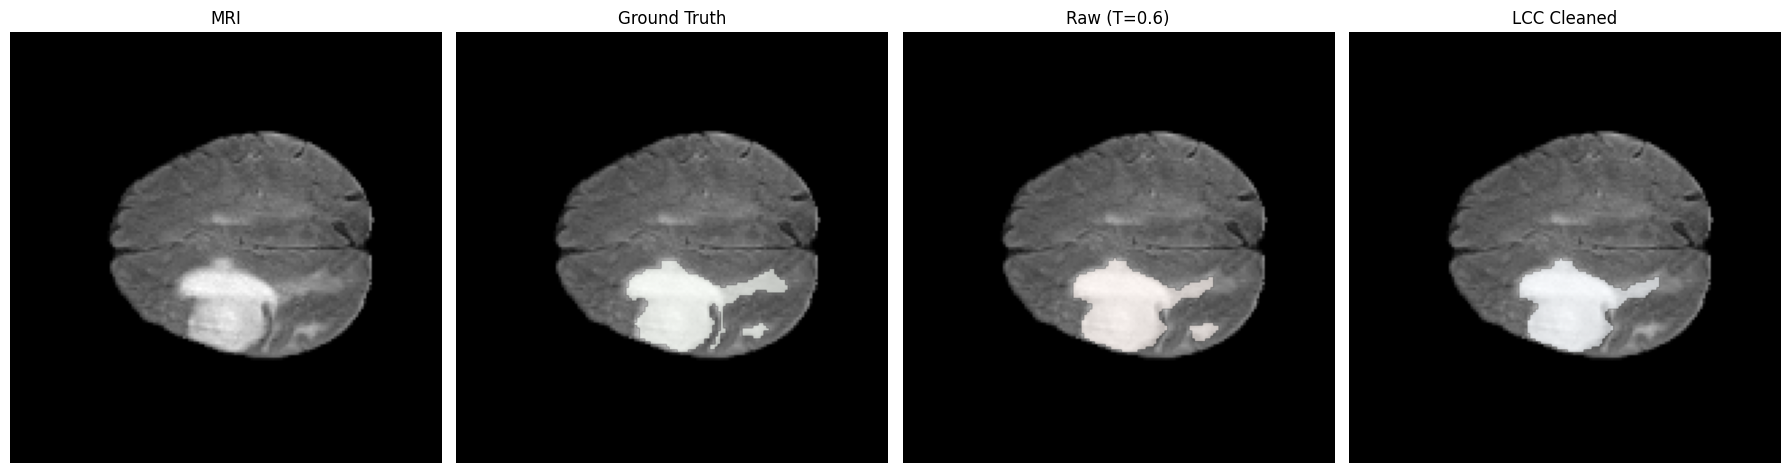

In [6]:
# ===== CELL 8: FINAL EVALUATION (LCC + DICE REPORT) =====

import scipy.ndimage as ndi
import numpy as np

model.load_state_dict(torch.load(f"{SAVE_DIR}/best.pth"))
model.eval()

def keep_largest_component(mask):
    labeled, num = ndi.label(mask)
    if num == 0:
        return mask
    sizes = ndi.sum(mask, labeled, range(1, num+1))
    largest = (sizes.argmax() + 1)
    return (labeled == largest)

found = False
for x, y in val_loader:
    for i in range(x.shape[0]):
        if y[i].sum() > 0:
            best_x = x[i].unsqueeze(0).to(device)
            best_y = y[i]
            found = True
            break
    if found:
        break

if found:
    with torch.no_grad():
        raw_out = model(best_x)[0]
        sig = torch.sigmoid(raw_out)

        optimal_threshold = 0.6

        raw_pred = (sig > optimal_threshold).cpu().numpy()[0][0]
        cleaned_pred = keep_largest_component(raw_pred)

    true_mask = best_y[0].cpu().numpy()

    # 🔬 Compute Dice
    def dice(a, b):
        inter = np.sum(a * b)
        union = np.sum(a) + np.sum(b)
        return (2 * inter) / (union + 1e-8)

    raw_dice = dice(raw_pred, true_mask)
    cleaned_dice = dice(cleaned_pred, true_mask)

    print(f"Raw Dice:     {raw_dice:.4f}")
    print(f"LCC Dice:     {cleaned_dice:.4f}")
    print(f"Improvement:  {cleaned_dice - raw_dice:.4f}")

    # Masking
    raw_masked = np.ma.masked_where(raw_pred == 0, raw_pred)
    cleaned_masked = np.ma.masked_where(cleaned_pred == 0, cleaned_pred)
    true_masked = np.ma.masked_where(true_mask == 0, true_mask)

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 4, 1)
    plt.title("MRI")
    plt.imshow(best_x[0][0].cpu(), cmap='gray')
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.title("Ground Truth")
    plt.imshow(best_x[0][0].cpu(), cmap='gray')
    plt.imshow(true_masked, alpha=0.6, cmap='Greens')
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.title(f"Raw (T={optimal_threshold})")
    plt.imshow(best_x[0][0].cpu(), cmap='gray')
    plt.imshow(raw_masked, alpha=0.6, cmap='Reds')
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.title("LCC Cleaned")
    plt.imshow(best_x[0][0].cpu(), cmap='gray')
    plt.imshow(cleaned_masked, alpha=0.6, cmap='Blues')
    plt.axis("off")

    plt.tight_layout()
    plt.show()

else:
    print("No tumor found.")

In [ ]:
# ===== FIGURE GENERATOR (PURE MATPLOTLIB) =====

import matplotlib.pyplot as plt

# 1. Set publication-quality styling
plt.rcParams.update({
    'font.size': 12, 
    'font.family': 'serif',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11
})

# --- FIGURE 2: TRAINING CONVERGENCE ---
epochs = list(range(1, 11))
train_loss = [0.3444, 0.2726, 0.2535, 0.2436, 0.2349, 0.2276, 0.2223, 0.2178, 0.2141, 0.2119]
val_dice = [0.8294, 0.8494, 0.8743, 0.8780, 0.8900, 0.8958, 0.9056, 0.9068, 0.9061, 0.9088]

fig, ax1 = plt.subplots(figsize=(8, 5))

# Add a subtle grid like Seaborn has
ax1.grid(True, linestyle='--', alpha=0.5)

color1 = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color=color1)
ax1.plot(epochs, train_loss, marker='s', color=color1, label="Train Loss", linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Validation Dice', color=color2)
ax2.plot(epochs, val_dice, marker='o', color=color2, label="Validation Dice", linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Training Convergence: Loss vs. Dice")
fig.tight_layout()

# This saves the image directly to your computer!
plt.savefig('figure2_convergence.png', dpi=300, bbox_inches='tight')
plt.show()

# --- FIGURE 5: THRESHOLD SENSITIVITY ---
thresholds = [0.3, 0.4, 0.5, 0.6]
dice_scores = [0.9062, 0.9077, 0.9085, 0.9088]

plt.figure(figsize=(6, 4))
plt.plot(thresholds, dice_scores, marker='o', color='tab:green', linewidth=2, markersize=8)
plt.xlabel("Global Threshold")
plt.ylabel("Validation Dice Score")
plt.title("Threshold Sensitivity Analysis")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# This saves the image directly to your computer!
plt.savefig('figure5_thresholds.png', dpi=300, bbox_inches='tight')
plt.show()